# Project Introduction

The Nintendo Switch is one of the most popular consoles released by the Japanese videogame developer, Nintendo. 

It was released on March 3rd, 2017. In the present work, we use data analytics to retrieve some insights on the Nintendo Switch VG collection lifespan. This data consists mostly of information provided by Nintendo and has been only updated until 2022.

## Project Introduction
We want to answer the following questions.
1. Who are the main developers of the catalogue?
2. Who are the main publishers of the catalogue?
3. On which year were the most games released?
4. What was the most popular game genre in terms of sales?
5. What are the best selling games?

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/best-selling-nintendo-switch-video-games/best_selling_switch_games.csv


In [2]:
#libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

- Data Exploration

In [3]:
db = pd.read_csv("/kaggle/input/best-selling-nintendo-switch-video-games/best_selling_switch_games.csv")
print(len(db))
db.head(10)

73


,title,copies_sold,genre,developer,publisher,as_of,release_date
0,Mario Kart 8 Deluxe,48410000.0,Kart racing,Nintendo EPD,Nintendo,2022-09-30,2017-04-28
1,Animal Crossing: New Horizons,40170000.0,Social simulation,Nintendo EPD,Nintendo,2022-09-30,2020-03-20
2,Super Smash Bros. Ultimate,29530000.0,Fighting,Bandai Namco StudiosSora Ltd.,Nintendo,2022-09-30,2018-12-07
3,The Legend of Zelda: Breath of the Wild,27790000.0,Action-adventure,Nintendo EPD,Nintendo,2022-09-30,2017-03-03
4,Pokémon Sword and Shield,25370000.0,Role-playing,Game Freak,The Pokémon CompanyNintendo,2022-09-30,2019-11-15
5,Super Mario Odyssey,24400000.0,Platformer,Nintendo EPD,Nintendo,2022-09-30,2017-10-27
6,Super Mario Party,18350000.0,Party,NDcube,Nintendo,2022-09-30,2018-10-05
7,Pokémon Brilliant Diamond and Shining Pearl,14920000.0,Role-playing,ILCA,The Pokémon CompanyNintendo,2022-09-30,2021-11-19
8,Ring Fit Adventure,14870000.0,Exergamerole-playing,Nintendo EPD,Nintendo,2022-09-30,2019-10-18
9,"Pokémon: Let's Go, Pikachu! and Let's Go, Eevee!",14810000.0,Role-playing,Game Freak,The Pokémon CompanyNintendo,2022-09-30,2018-11-16


In [4]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         73 non-null     object 
 1   copies_sold   73 non-null     float64
 2   genre         73 non-null     object 
 3   developer     73 non-null     object 
 4   publisher     73 non-null     object 
 5   as_of         73 non-null     object 
 6   release_date  73 non-null     object 
dtypes: float64(1), object(6)
memory usage: 4.1+ KB


In [5]:
db["release_date"] = pd.to_datetime(db["release_date"], format="%Y-%m-%d")
db["copies_sold"] = db["copies_sold"]
db["year"] = db["release_date"].dt.year
db.head(3)

,title,copies_sold,genre,developer,publisher,as_of,release_date,year
0,Mario Kart 8 Deluxe,48410000.0,Kart racing,Nintendo EPD,Nintendo,2022-09-30,2017-04-28,2017
1,Animal Crossing: New Horizons,40170000.0,Social simulation,Nintendo EPD,Nintendo,2022-09-30,2020-03-20,2020
2,Super Smash Bros. Ultimate,29530000.0,Fighting,Bandai Namco StudiosSora Ltd.,Nintendo,2022-09-30,2018-12-07,2018


*Only 74 entries of the best selling games of the Switch as of 2022*

## 1. Group by developers

In [6]:
dev = db.groupby("developer").agg({
    "copies_sold": "sum",
    "developer": "count"
})

dev = dev.sort_values("copies_sold", ascending=False)
dev["ratio_per_game"] = (dev["copies_sold"] / dev["developer"]).round()
dev = dev.sort_values("ratio_per_game", ascending=False)

# Format numbers only for display
dev["copies_sold"] = dev["copies_sold"].map("{:,}".format)
dev["ratio_per_game"] = dev["ratio_per_game"].map("{:,}".format)

dev.head()

,copies_sold,developer,ratio_per_game
developer,,,
Bandai Namco StudiosSora Ltd.,"29,530,000.0",1,"29,530,000.0"
Game Freak,"64,090,000.0",4,"16,022,500.0"
ILCA,"14,920,000.0",1,"14,920,000.0"
Nintendo EPD,"226,110,000.0",17,"13,300,588.0"
NDcube,"30,640,000.0",3,"10,213,333.0"


## 2. Group by publisher

In [7]:
pub = db.groupby("publisher").agg({'copies_sold': 'sum',"publisher":"count"})
pub = pub.sort_values("copies_sold",ascending = False)
pub["ratio_per_game"] = (pub["copies_sold"]/pub["publisher"]).round()
pub = pub.rename(columns={"publisher": "games_by_pub"})

# Format numbers only for display
pub["copies_sold"] = pub["copies_sold"]
pub["ratio_per_game"] = pub["ratio_per_game"].map("{:,}".format)

pub.head()

,copies_sold,games_by_pub,ratio_per_game
publisher,,,
Nintendo,371520000.0,47,"7,904,681.0"
The Pokémon CompanyNintendo,79010000.0,5,"15,802,000.0"
Capcom,8900000.0,2,"4,450,000.0"
Bandai Namco Entertainment,6710000.0,4,"1,677,500.0"
JP: The Pokémon CompanyNA/PAL: Nintendo,4280000.0,2,"2,140,000.0"


In [8]:
pub = pub.reset_index()

top3 = pub.nlargest(3, "copies_sold")
others = pub.loc[~pub.index.isin(top3.index), "copies_sold"].sum()
top3.loc["Others","copies_sold"] = others
top3.loc["Others","publisher"] = "Others"
top3 = top3[["publisher","copies_sold"]]
top3

,publisher,copies_sold
0,Nintendo,371520000.0
1,The Pokémon CompanyNintendo,79010000.0
2,Capcom,8900000.0
Others,Others,36160000.0


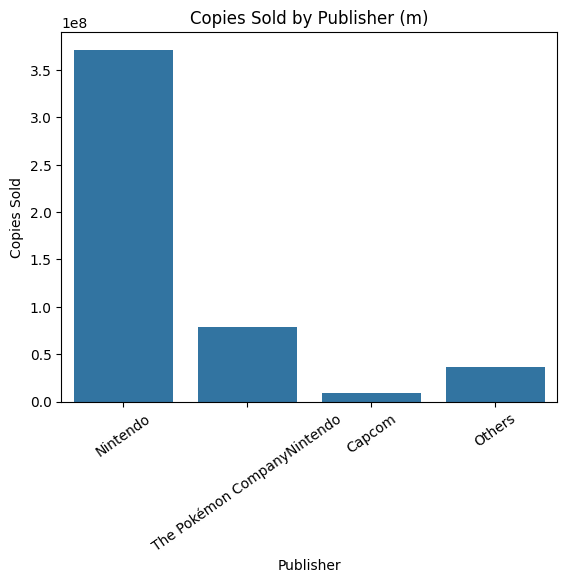

In [9]:
sns.barplot(data=top3, x="publisher", y="copies_sold")

plt.title("Copies Sold by Publisher (m)")
plt.xlabel("Publisher")
plt.ylabel("Copies Sold")
plt.xticks(rotation=35)

plt.show()

## 3. Most games released

In [10]:
game_rel = db.groupby("year").agg({'copies_sold': 'sum',"year":"count"})
game_rel = game_rel.sort_values("copies_sold",ascending = False)
game_rel["ratio_per_game"] = (game_rel["copies_sold"]/game_rel["year"]).round()
game_rel = game_rel.rename(columns={"year": "games_released"})

# Format numbers only for display
game_rel["copies_sold"] = game_rel["copies_sold"]
game_rel["ratio_per_game"] = game_rel["ratio_per_game"].map("{:,}".format)
game_rel = game_rel.reset_index()
game_rel.head()

,year,copies_sold,games_released,ratio_per_game
0,2017,134490000.0,14,"9,606,429.0"
1,2019,90760000.0,12,"7,563,333.0"
2,2018,86720000.0,13,"6,670,769.0"
3,2020,75880000.0,12,"6,323,333.0"
4,2021,59620000.0,14,"4,258,571.0"


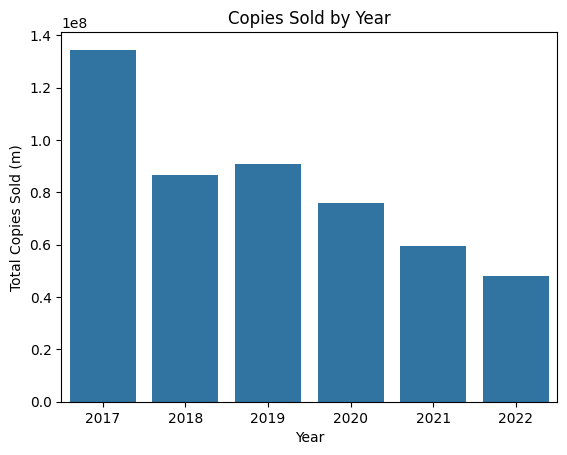

In [11]:
sns.barplot(data=game_rel, x="year", y="copies_sold")

plt.title("Copies Sold by Year")
plt.xlabel("Year")
plt.ylabel("Total Copies Sold (m)")

plt.show()

## 4. Top Genres

In [12]:
genre_cat = db.groupby("genre").agg({'copies_sold': 'sum',"genre":"count"})
genre_cat = genre_cat.sort_values("copies_sold",ascending = False)
genre_cat["ratio_per_game"] = (genre_cat["copies_sold"]/genre_cat["genre"]).round()

# Format numbers only for display
genre_cat["copies_sold"] = genre_cat["copies_sold"].map("{:,}".format)
genre_cat["ratio_per_game"] = genre_cat["ratio_per_game"].map("{:,}".format)

genre_cat.head()

,copies_sold,genre,ratio_per_game
genre,,,
Role-playing,"69,940,000.0",7,"9,991,429.0"
Platformer,"63,520,000.0",7,"9,074,286.0"
Action-adventure,"52,110,000.0",5,"10,422,000.0"
Kart racing,"48,410,000.0",1,"48,410,000.0"
Social simulation,"40,170,000.0",1,"40,170,000.0"


## 5. Best Selling Games

In [13]:
db.head(5)

,title,copies_sold,genre,developer,publisher,as_of,release_date,year
0,Mario Kart 8 Deluxe,48410000.0,Kart racing,Nintendo EPD,Nintendo,2022-09-30,2017-04-28,2017
1,Animal Crossing: New Horizons,40170000.0,Social simulation,Nintendo EPD,Nintendo,2022-09-30,2020-03-20,2020
2,Super Smash Bros. Ultimate,29530000.0,Fighting,Bandai Namco StudiosSora Ltd.,Nintendo,2022-09-30,2018-12-07,2018
3,The Legend of Zelda: Breath of the Wild,27790000.0,Action-adventure,Nintendo EPD,Nintendo,2022-09-30,2017-03-03,2017
4,Pokémon Sword and Shield,25370000.0,Role-playing,Game Freak,The Pokémon CompanyNintendo,2022-09-30,2019-11-15,2019


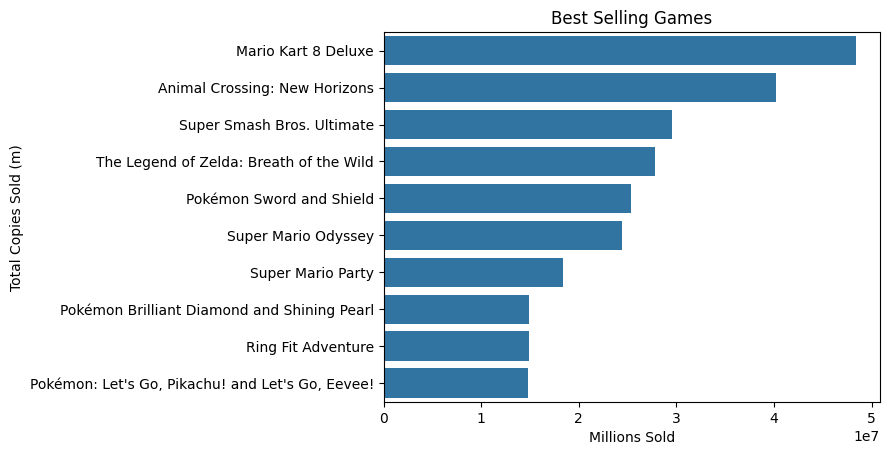

In [14]:
sns.barplot(data=db[:10], x="copies_sold", y="title")
plt.title("Best Selling Games")
plt.xlabel("Millions Sold")
plt.ylabel("Total Copies Sold (m)")
plt.show()

# Insights

Work still in progress, to mention.

- Nintendo's Powerful and exclusive power as a publisher. Most games in the list are Nintendo's.
- What is the relationship between publisher and developer?
- The Nintendo Switch Catalogue's success has been constant and not a launch only success

What Nintendo can gain from the success

Limitations
- This is only a list updated as late of 2022. Nintendo keeps their numbers close to their chest. For these reasons the least successful titles are not included here. To have a better understanding between the real success of the investment of Nintendo in developing their own titles a full database would be useful to compare it to the success of third parties bringing their own games into the platform.